In [ ]:
# Resstock to Urbanopt building characterisitics disaggregation 
# Prediciting building characterisitcs using ResStock data 

"""
Created on May 04 12:00:00 2024

@authors: Rawad El Kontar

reference: https://docs.nrel.gov/docs/fy24osti/90883.pdf 

citation: 
El Kontar, Rawad, et al. 
An Open-Source Framework for Characterizing Urban Energy Models: 
Integrating Top-Down and Bottom-Up Methods to Predict Residential Buildings Characteristics.
No. NREL/CP-5500-90883. National Renewable Energy Laboratory (NREL), Golden, CO (United States), 2024.

"""

In [ ]:
pip install scikit-learn

In [1]:
import os
import json
import random
import numpy as np
from datetime import datetime
import time
from collections import defaultdict
import pandas as pd
import gzip
import csv
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import normalize
from collections import defaultdict
import math
import pandas as pd

df = pd.read_csv('NY_baseline_metadata_and_annual_results.csv')

print('done')

done


/var/folders/ln/6yl4tj8929b1krzhjfv011sh0000gr/T/ipykernel_46888/2586470971.py:18: DtypeWarning: Columns (132) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('NY_baseline_metadata_and_annual_results.csv')


In [2]:
# Extract input and output variables
#input_columns = [col for col in df.columns if col.startswith('in.')]
output_variable = 'out.site_energy.total.energy_consumption.kwh'
input_columns = [
    
'bldg_id', #
  
'in.sqft',
    
 'in.area_median_income',#
    
 'in.battery',
 'in.bedrooms',
 'in.ceiling_fan',
 'in.clothes_dryer',
 'in.clothes_dryer_usage_level',
 'in.clothes_washer',
 'in.clothes_washer_presence',
 'in.clothes_washer_usage_level',
 'in.cooking_range',
 'in.cooking_range_usage_level',
 'in.cooling_setpoint',
 'in.cooling_setpoint_has_offset',
 'in.cooling_setpoint_offset_magnitude',
 'in.cooling_setpoint_offset_period',
 'in.corridor',
 'in.dishwasher',
 'in.dishwasher_usage_level',
 'in.door_area',
 'in.duct_leakage_and_insulation',
 'in.duct_location',

 'in.federal_poverty_level',#
                 
 'in.geometry_attic_type',
    
 'in.geometry_building_horizontal_location_mf',#
 'in.geometry_building_horizontal_location_sfa',#
 'in.geometry_building_level_mf',#
 'in.geometry_building_number_units_mf',#
 'in.geometry_building_number_units_sfa',#


 'in.geometry_building_type_recs',
 'in.geometry_floor_area', #
 'in.geometry_floor_area_bin',
 'in.geometry_foundation_type',
 'in.geometry_garage',
 'in.geometry_stories',
 'in.geometry_stories_low_rise',
 'in.geometry_story_bin',
 'in.geometry_wall_exterior_finish',
 'in.geometry_wall_type',
    
 'in.has_pv',
 'in.heating_fuel',
 'in.heating_setpoint',
 'in.heating_setpoint_has_offset',
 'in.heating_setpoint_offset_magnitude',
 'in.heating_setpoint_offset_period',
 'in.holiday_lighting',
 'in.hot_water_distribution',
 'in.hot_water_fixtures',
                 
 'in.household_has_tribal_persons',#
                 
 'in.hvac_cooling_efficiency',
 'in.hvac_cooling_partial_space_conditioning',
 'in.hvac_cooling_type',
 'in.hvac_has_ducts',
 'in.hvac_has_shared_system',
 'in.hvac_has_zonal_electric_heating',
 'in.hvac_heating_efficiency',
 'in.hvac_heating_type',
 'in.hvac_heating_type_and_fuel',

 'in.hvac_shared_efficiencies',#
    
 'in.income_recs_2020',
    
 'in.infiltration',
 'in.insulation_ceiling',
 'in.insulation_floor',
 'in.insulation_foundation_wall',
 'in.insulation_rim_joist',
 'in.insulation_roof',
 'in.insulation_slab',
 'in.insulation_wall',
 'in.interior_shading',

 'in.lighting',
 'in.lighting_interior_use',
 'in.lighting_other_use',

 'in.mechanical_ventilation',
 'in.misc_extra_refrigerator',
 'in.misc_freezer',
 'in.misc_gas_fireplace',
 'in.misc_gas_grill',
 'in.misc_gas_lighting',
 'in.misc_hot_tub_spa',
 'in.misc_pool',
 'in.misc_pool_heater',#
 'in.misc_pool_pump',#
 'in.misc_well_pump',#
 'in.natural_ventilation',
 'in.neighbors',
 'in.occupants',
 'in.orientation',
 'in.overhangs',
 'in.plug_load_diversity',
 'in.plug_loads',

 'in.pv_orientation',
 'in.pv_system_size',
 'in.radiant_barrier',

 'in.refrigerator',
 'in.refrigerator_usage_level',
 'in.roof_material',

 'in.solar_hot_water',

 'in.tenure',

 'in.usage_level',

 'in.vacancy_status',
 'in.vintage', #
 'in.vintage_acs',
 'in.water_heater_efficiency',
 'in.water_heater_fuel',
 'in.water_heater_in_unit',

 'in.window_areas',
 'in.windows',
 'in.representative_income'#
                ]

# Create the new DataFrame with input and output variables
new_df = df[input_columns + [output_variable]]

In [ ]:
new_df.head()
new_df.to_csv('cleandata_for_importance_sampling.csv', index = False)

## SENSITIVITY ANALYSIS USING RANDOM FOREST 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# === Step 1: Prepare Data ===

def convert_to_string(X):
    return X.astype(str)

data = new_df.copy()
data = data.drop(columns=['in.sqft'])

# === Filter unwanted window categories BEFORE split ===

# Normalize the 'in.windows' column
data['in.windows'] = data['in.windows'].astype(str).str.strip().str.lower()

# List of categories to drop (in lowercase)
bad_cats = [
    'double, clear, non-metal, air, exterior clear storm',
    'single, clear, metal, exterior clear storm',
    'single, clear, non-metal, exterior clear storm',
    'triple, low-e, non-metal, air, l-gain'
]

# Drop rows with those window types
data = data[~data['in.windows'].isin(bad_cats)]

# Sanity check
print("✅ Remaining in.windows categories:")
print(data['in.windows'].unique())

# === Split X and y ===
X = data.drop(columns=['out.site_energy.total.energy_consumption.kwh'])
y = data['out.site_energy.total.energy_consumption.kwh'].astype(float)

# Drop numeric columns that are all-NaN
na_cols = X.select_dtypes(include=['float64', 'int64']).columns[X.select_dtypes(include=['float64', 'int64']).isna().all()].tolist()
print("🔍 Dropping all-NaN numerical columns:", na_cols)
X = X.drop(columns=na_cols)

# Recalculate column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()


✅ Remaining in.windows categories:
['double, clear, non-metal, air' 'double, low-e, non-metal, air, m-gain'
 'single, clear, non-metal' 'single, clear, metal'
 'double, clear, metal, air'
 'double, clear, metal, air, exterior clear storm']
🔍 Dropping all-NaN numerical columns: ['in.battery', 'in.mechanical_ventilation', 'in.overhangs', 'in.solar_hot_water']


In [4]:

# === Step 2: Define Preprocessing ===

numerical_transformer = SimpleImputer(strategy='median')

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('to_string', FunctionTransformer(convert_to_string, validate=False)),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [5]:

# === Step 3: Build Model Pipeline ===

model = RandomForestRegressor(n_estimators=100, random_state=0)

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])


In [6]:

# === Step 4: Train/Test Split ===
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)

# === Step 5: Fit Model ===
clf.fit(X_train, y_train)

# === Step 6: Extract Feature Names and Importances ===
ohe = clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_feature_names = ohe.get_feature_names_out(input_features=categorical_cols)
feature_names = np.r_[numerical_cols, categorical_feature_names]

importances = clf.named_steps['model'].feature_importances_

print(f"length of importances: {len(importances)}")
print(f"length of feature names: {len(feature_names)}")

assert len(importances) == len(feature_names), "❌ Feature count mismatch!"


length of importances: 557
length of feature names: 557


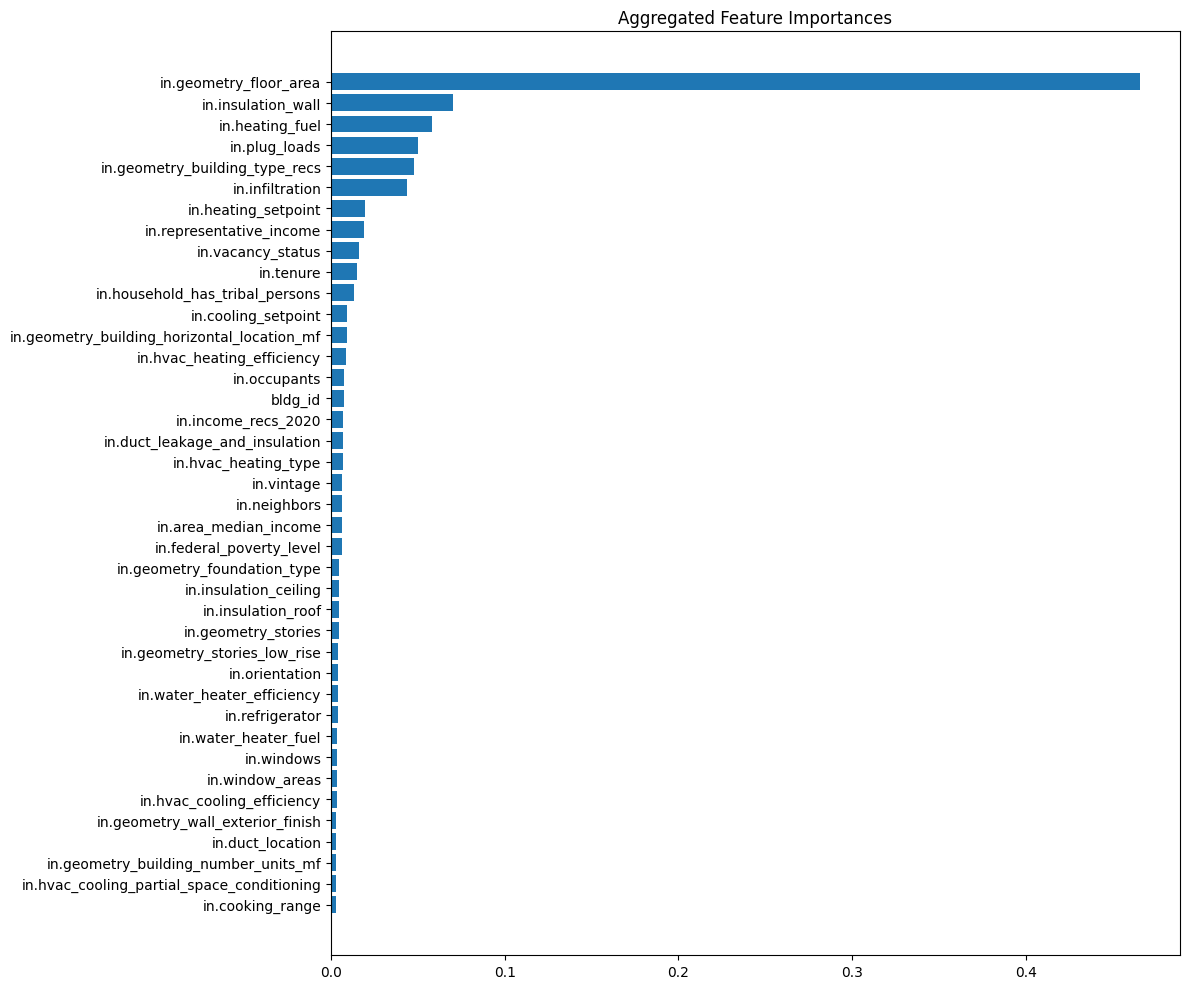

✅ Exported feature importances to aggregated_feature_importances.csv


In [7]:

# === Step 7: Aggregate Importances by Original Feature ===
original_feature_importances = dict(zip(numerical_cols, importances[:len(numerical_cols)]))

for i, feature in enumerate(feature_names[len(numerical_cols):]):
    for col in categorical_cols:
        if feature.startswith(f"{col}_"):
            original_name = col
            break
    else:
        original_name = "unknown"
    original_feature_importances[original_name] = original_feature_importances.get(original_name, 0) + importances[i + len(numerical_cols)]

sorted_features = sorted(original_feature_importances.items(), key=lambda x: x[1], reverse=True)

# === Step 8: Plot ===
plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")
N = 40
top_features = sorted_features[:N]
plt.barh(range(N), [val for _, val in top_features])
plt.yticks(range(N), [key for key, _ in top_features])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === Step 9: Export to CSV ===
feature_df = pd.DataFrame(sorted_features, columns=["Feature", "Importance"])
feature_df.to_csv("aggregated_feature_importances.csv", index=False)
print("✅ Exported feature importances to aggregated_feature_importances.csv")


In [ ]:
# # CHECK!!!!

# # Convert to lists
# feature_names_list = list(feature_names)
# importances_list = list(importances)

# # Debug: Print lengths
# print("🔍 feature_names length:", len(feature_names_list))
# print("🔍 importances length:", len(importances_list))

# # Export separately
# pd.Series(feature_names_list, name="Feature_Name").to_csv("feature_names_list.csv", index=False)
# pd.Series(importances_list, name="Importance").to_csv("importances_list.csv", index=False)

# print("✅ Exported feature_names_list.csv and importances_list.csv")


# # Save mismatched tails, if any
# if len(feature_names_list) > len(importances_list):
#     pd.Series(feature_names_list[len(importances_list):], name="Extra_Feature_Names")\
#       .to_csv("extra_feature_names.csv", index=False)
#     print("⚠️ Extra feature names saved to extra_feature_names.csv")

# elif len(importances_list) > len(feature_names_list):
#     pd.Series(importances_list[len(feature_names_list):], name="Extra_Importances")\
#       .to_csv("extra_importances.csv", index=False)
#     print("⚠️ Extra importances saved to extra_importances.csv")
# print('done')

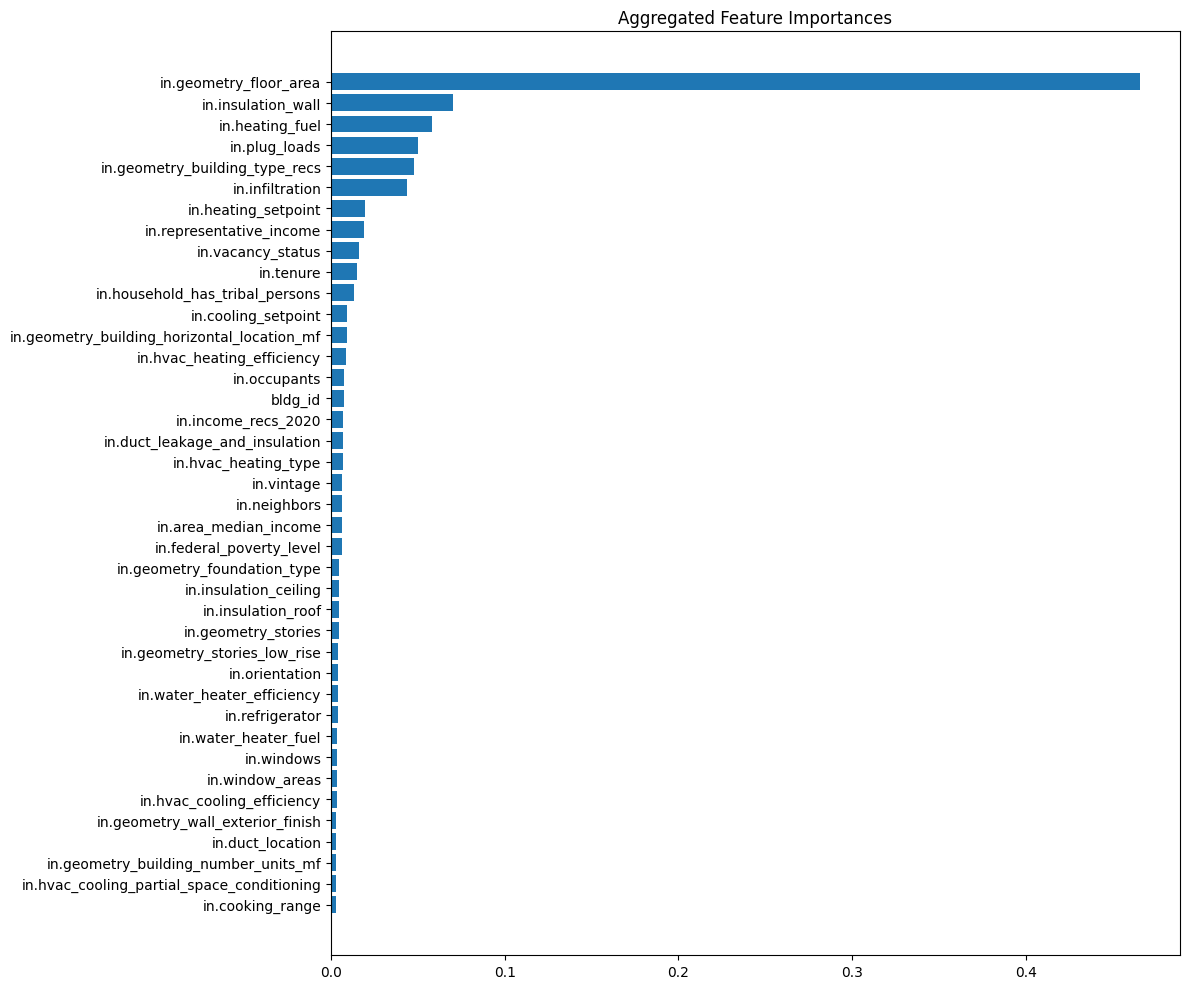

In [10]:
## SAVE 
plt.figure(figsize=(12, 10))
plt.title("Aggregated Feature Importances")

N = 40

top_features = sorted_features[:N]
bars = plt.barh(range(N), [val for _, val in top_features])

plt.yticks(range(N), [key for key, _ in top_features], rotation=0)
plt.gca().invert_yaxis() 
plt.tight_layout()  
plt.savefig('feature_importances_plot.png')
plt.show()


sorted_features_df = pd.DataFrame(sorted_features, columns=['Feature', 'Importance'])
sorted_features_df.to_csv('sorted_feature_importances.csv', index=False)


# DEVELOPING A MODEL TO PREDICT

In [11]:
import pandas as pd

sorted_features_df = pd.read_csv('sorted_feature_importances.csv')

data_all_inputs = new_df

top_20_features = sorted_features_df['Feature'].head(20).tolist()

top_20_features.append('out.site_energy.total.energy_consumption.kwh')
top_20_features.insert(0,'bldg_id')

top_20_features.extend(['in.bedrooms','in.geometry_stories',\
                       'in.geometry_building_number_units_mf',\
                      'in.vintage_acs', 'in.hvac_cooling_type',\
                      'in.geometry_wall_type','in.roof_material',\
                    'in.geometry_garage','in.geometry_attic_type']) # add it for testing


selected_data = data_all_inputs[top_20_features]

selected_data.head()

# save the csv
#selected_data.to_csv('selected_data.csv')

,bldg_id,in.geometry_floor_area,in.insulation_wall,in.heating_fuel,in.plug_loads,in.geometry_building_type_recs,in.infiltration,in.heating_setpoint,in.representative_income,in.vacancy_status,...,out.site_energy.total.energy_consumption.kwh,in.bedrooms,in.geometry_stories,in.geometry_building_number_units_mf,in.vintage_acs,in.hvac_cooling_type,in.geometry_wall_type,in.roof_material,in.geometry_garage,in.geometry_attic_type
0,34,1500-1999,"Wood Stud, R-11",Electricity,108%,Single-Family Attached,6 ACH50,60F,92315.0,Occupied,...,16767.768209,2,2,NaN,1980-99,Room AC,Wood Frame,"Asphalt Shingles, Medium",NaN,Vented Attic
1,41,2000-2499,"Wood Stud, Uninsulated",Fuel Oil,101%,Single-Family Detached,15 ACH50,70F,270137.0,Occupied,...,49699.871293,3,2,NaN,<1940,Central AC,Wood Frame,Slate,NaN,Finished Attic or Cathedral Ceilings
2,45,2000-2499,"Wood Stud, R-11",Natural Gas,101%,Single-Family Detached,6 ACH50,75F,128932.0,Occupied,...,45719.966160,4,1,NaN,1980-99,Central AC,Wood Frame,Composition Shingles,NaN,Vented Attic
3,59,2500-2999,"Wood Stud, R-7",Natural Gas,101%,Single-Family Detached,15 ACH50,70F,169093.0,Occupied,...,58080.531616,2,2,NaN,1960-79,Room AC,Wood Frame,"Metal, Dark",2 Car,Unvented Attic
4,65,1500-1999,"Wood Stud, Uninsulated",Natural Gas,108%,Single-Family Attached,20 ACH50,70F,189099.0,Occupied,...,32449.708103,3,3,NaN,<1940,Room AC,Wood Frame,Composition Shingles,NaN,NaN


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors

df = selected_data

# Identify categorical variables
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()

# Identify numeric variables
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# New buildings data known variables 
new_building = pd.DataFrame({'in.geometry_building_type_recs': ['Single-Family Detached'], 
                   'in.geometry_floor_area': ['2500-2999'], 
                   'in.heating_fuel': ['Natural Gas'],
                    'in.bedrooms':[3],
                    'in.geometry_stories': [3],
                    #'in.occupants':['3'],
                    #'out.site_energy.total.energy_consumption.kwh':[30000]
                             }, index=[0])


# Define the number of matches you want to find
n_matches = 10

relevant_columns = new_building.columns.tolist()
df_relevant = df[relevant_columns + ['bldg_id']]  # Include 'bldg_id' for identification


df_relevant_fixed = df_relevant.fillna('missing')
df_relevant_fixed[relevant_columns] = df_relevant_fixed[relevant_columns].astype(str)

new_building_fixed = new_building.fillna('missing')
new_building_fixed[relevant_columns] = new_building_fixed[relevant_columns].astype(str)

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, relevant_columns)
])

df_relevant_transformed_fixed = preprocessor.fit_transform(df_relevant_fixed.drop(columns=['bldg_id']))
new_building_transformed_fixed = preprocessor.transform(new_building_fixed)

# NearestNeighbors to find the closest matches
neighbors = NearestNeighbors(n_neighbors=n_matches)
neighbors.fit(df_relevant_transformed_fixed)
distances_fixed, indices_fixed = neighbors.kneighbors(new_building_transformed_fixed)

for i, (new_building_indices, new_building_distances) in enumerate(zip(indices_fixed, distances_fixed)):
    print(f"New Building {i+1} Closest Matches:")
    for j, (match_index, distance) in enumerate(zip(new_building_indices, new_building_distances)):
        bldg_id = df_relevant_fixed.iloc[match_index]['bldg_id']
        print(f"  Match {j+1}: bldg_id {bldg_id} with distance {distance:.2f}")
    print()  


New Building 1 Closest Matches:
  Match 1: bldg_id bldg_id    139004
bldg_id    139004
Name: 8611, dtype: object with distance 0.00
  Match 2: bldg_id bldg_id    246438
bldg_id    246438
Name: 15175, dtype: object with distance 0.00
  Match 3: bldg_id bldg_id    186637
bldg_id    186637
Name: 11514, dtype: object with distance 0.00
  Match 4: bldg_id bldg_id    437985
bldg_id    437985
Name: 26992, dtype: object with distance 0.00
  Match 5: bldg_id bldg_id    25626
bldg_id    25626
Name: 1593, dtype: object with distance 0.00
  Match 6: bldg_id bldg_id    295031
bldg_id    295031
Name: 18133, dtype: object with distance 0.00
  Match 7: bldg_id bldg_id    87523
bldg_id    87523
Name: 5471, dtype: object with distance 0.00
  Match 8: bldg_id bldg_id    57969
bldg_id    57969
Name: 3622, dtype: object with distance 0.00
  Match 9: bldg_id bldg_id    56020
bldg_id    56020
Name: 3502, dtype: object with distance 0.00
  Match 10: bldg_id bldg_id    311227
bldg_id    311227
Name: 19156, dty

In [19]:
# Initialize lists to store the new indices and their corresponding lowest distances
lowest_indices = []
lowest_distances = []
nearest_neighbor_bldgs = []

# Iterate over each set of distances for the new buildings
for i, distances in enumerate(distances_fixed):
    min_distance = np.min(distances)
    min_indices = np.where(distances == min_distance)[0]
    actual_indices = indices_fixed[i][min_indices]
    
    actual_distances = distances[min_indices]
    lowest_indices.append(actual_indices)
    lowest_distances.append(actual_distances)

    #Get building IDs for the nearest neighbors
    nearest_neighbor_ids = df_relevant_fixed.iloc[actual_indices]['bldg_id'].values
    nearest_neighbor_bldgs.append(nearest_neighbor_ids)
    
print("\n🧱 Matched Building Properties:\n")

df = df.loc[:, ~df.columns.duplicated()]

for idx, (dist, bldg_ids) in enumerate(zip(lowest_distances[0], nearest_neighbor_bldgs[0])):
    # Ensure we handle cases where bldg_ids might be an array
    if isinstance(bldg_ids, (np.ndarray, list)):
        bldg_ids = bldg_ids.tolist()
    else:
        bldg_ids = [bldg_ids]

    for b_id in bldg_ids:
        match_row = df[df['bldg_id'] == b_id].iloc[0]

        print(f"🔹 Match {idx+1}: Building ID = {b_id}, Distance = {dist:.2f}")
        for col in relevant_columns:
            print(f"   {col}: {match_row[col]}")
        print("-" * 50)



🧱 Matched Building Properties:

🔹 Match 1: Building ID = 139004, Distance = 0.00
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 2500-2999
   in.heating_fuel: Natural Gas
   in.bedrooms: 3
   in.geometry_stories: 3
--------------------------------------------------
🔹 Match 1: Building ID = 139004, Distance = 0.00
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 2500-2999
   in.heating_fuel: Natural Gas
   in.bedrooms: 3
   in.geometry_stories: 3
--------------------------------------------------
🔹 Match 2: Building ID = 246438, Distance = 0.00
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 2500-2999
   in.heating_fuel: Natural Gas
   in.bedrooms: 3
   in.geometry_stories: 3
--------------------------------------------------
🔹 Match 2: Building ID = 246438, Distance = 0.00
   in.geometry_building_type_recs: Single-Family Detached
   in.geometry_floor_area: 2500-2999
   in.heat